# Superstore Sales Analysis

The dataset can be found here:
[Superstore Sales Dataset](https://public.tableau.com/app/learn/sample-data)

## Objective
Analyze business performance and predict profit

## Key Insights
- Discounts negatively impact profit
- Technology category is most profitable

## Tools
Python, Pandas, Plotly, Scikit-learn

## Results
- Built dashboard
- ML model MAE: XX

# Project Summary

This project analyzes the Superstore dataset to explore sales performance, profitability, and key business drivers. A dashboard was built to visualize trends and patterns, and a machine learning model was developed to predict profit based on transactional features.

# Steps

## Step 1: Load Data

Read CSV with pandas

Check:

*   missing values
*   data types



## Step 2: Data Cleaning

Handle null values

Convert dates

Remove duplicates

## Step 3: Exploratory Data Analysis (EDA)

Answer these:
* Total sales over time
* Top 10 products
* Sales by region
* Most profitable category

## Step 4: Visualization

Use:
* matplotlib / seaborn

Create:
* Line chart (sales over time)
* Bar chart (top products)
* Pie chart (category share)

## Step 5: Business Insights (IMPORTANT)

This is what makes you stand out.

Write insights like:
* “Region X generates highest revenue but low profit”
* “Category Y has high sales but low margin”

## Step 6: Export Results

Save summary as CSV

Save charts as images

# Download Data

In [172]:
from google.colab import files
uploaded = files.upload()

Saving superstore_sales_dataset.xls to superstore_sales_dataset (1).xls


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load data
df = pd.read_excel('superstore_sales_dataset.xls')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


# Step 1: Data Cleaning

In [ ]:
# Clean
#df['Order Date'] = pd.to_datetime(df['Order Date'])
#df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Feature engineering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Profit Margin'] = df['Profit']/df['Sales']

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Profit Margin
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,0.3375
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,-1.5500
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,0.3625
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,-0.2375
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,0.2500


# Step 2: Exploratory Data Analysis (EDA)

Focus on business questions (this is what gets you hired):

Key questions:
* Which category is most profitable?
* Does discount reduce profit?
* Which region performs best?

In [ ]:
# Sales by region
sales_by_region = df.groupby('Region')['Sales'].sum()

print(sales_by_region)

Region
Central    503170.6728
East       691828.1680
South      391721.9050
West       739813.6085
Name: Sales, dtype: float64


## Visualizations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

### 2.1 Sales over Time (Trend)

Insight: Seasonality, growth trend

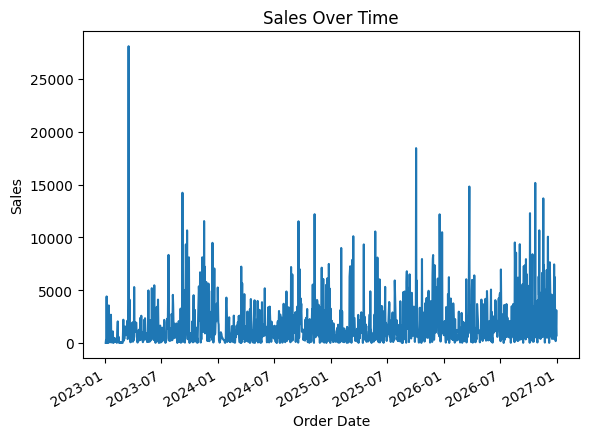

In [ ]:
sales_trend = df.groupby('Order Date')['Sales'].sum()

plt.figure()
sales_trend.plot()
plt.title('Sales Over Time')
plt.ylabel('Sales')
plt.show()

### 2.2 Sales by Category

Insight: Which category makes the most money

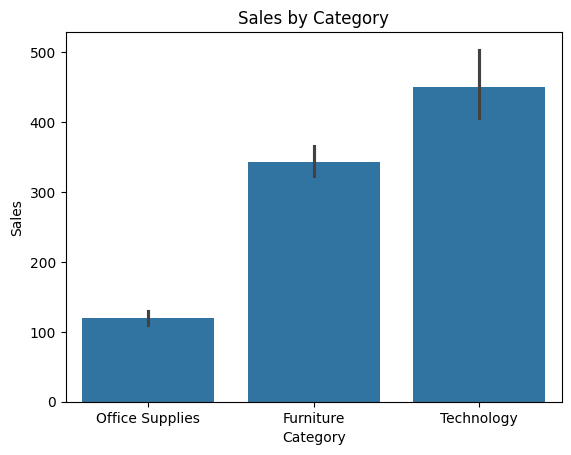

In [ ]:
sns.barplot(x = 'Category', y = 'Sales', data = df)
plt.title('Sales by Category')
plt.show()

### 2.3 Profit by Category

Insight: Some categories have high sales but low profit

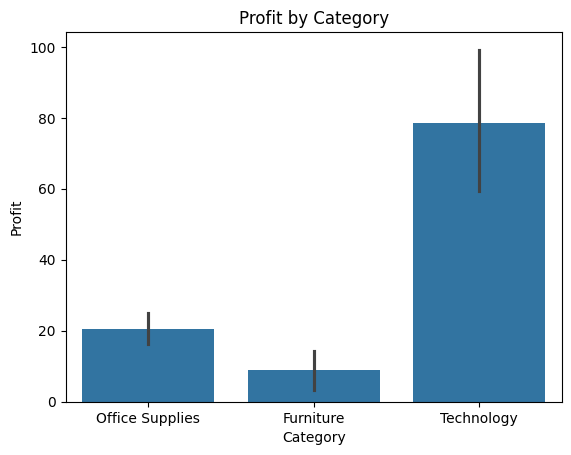

In [ ]:
sns.barplot(x = 'Category', y = 'Profit', data = df)
plt.title('Profit by Category')
plt.show()

### 2.4 Sales by Region

Insight: Geographic performance

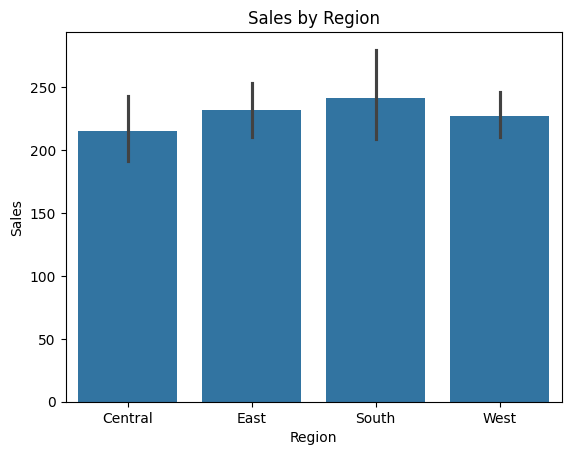

In [ ]:
sns.barplot(x = 'Region', y = 'Sales', data = df)
plt.title('Sales by Region')
plt.show()

### 2.5 Correlation Heatmap

Insight: Discount vs Profit

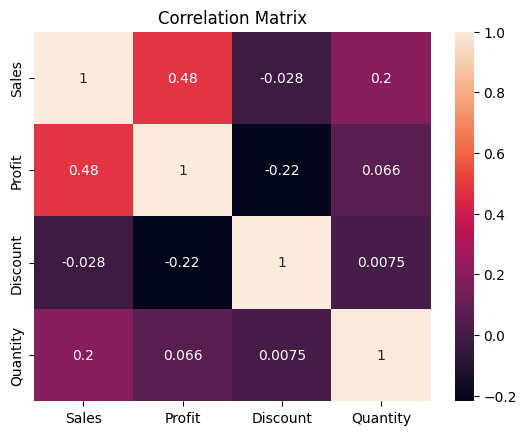

In [ ]:
corr = df[['Sales', 'Profit', 'Discount', 'Quantity']].corr()

sns.heatmap(corr, annot = True)
plt.title('Correlation Matrix')
plt.show()

From the correlation matrix, Discount is negatively correlated with Profit, indicating that higher discounts tend to reduce profitability.

In addition, Discount shows a negative relationship with Sales but a positive correlation with Quantity. This suggests that while discounts may encourage customers to purchase more items, they often do so at the expense of overall revenue and profit.

### 2.6 Discount vs Profit

Insight: High discounts often → losses

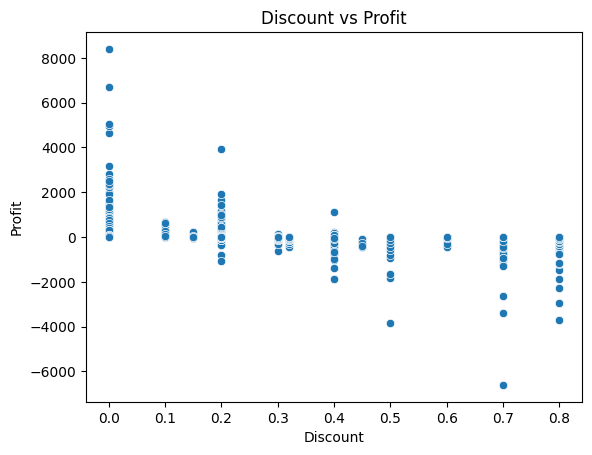

In [ ]:
sns.scatterplot(x = 'Discount', y = 'Profit', data = df)
plt.title("Discount vs Profit")
plt.show()

### 2.7 Monthly Sales Trend

Insight: Seasonality (e.g., year-end spikes)

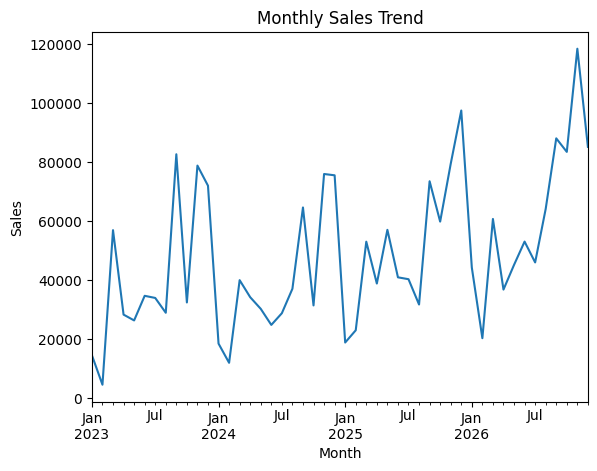

In [ ]:
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()

### 2.8 Boxplot for Profit (Outliers)

Insight: Loss-making orders

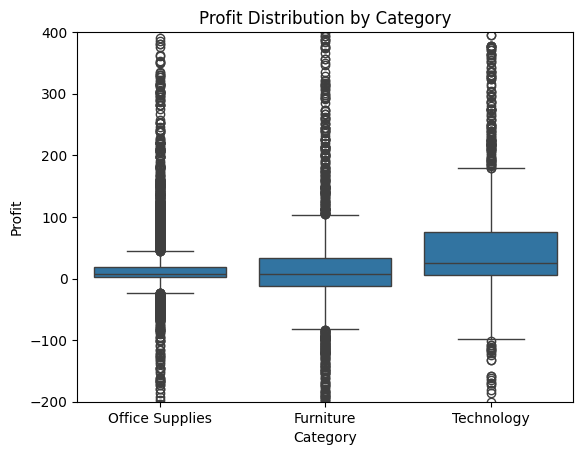

In [ ]:
sns.boxplot(x = 'Category', y = 'Profit', data = df)
plt.title('Profit Distribution by Category')
plt.ylim(-200, 400)
plt.show()

### 2.9 Top 10 Products by Sales

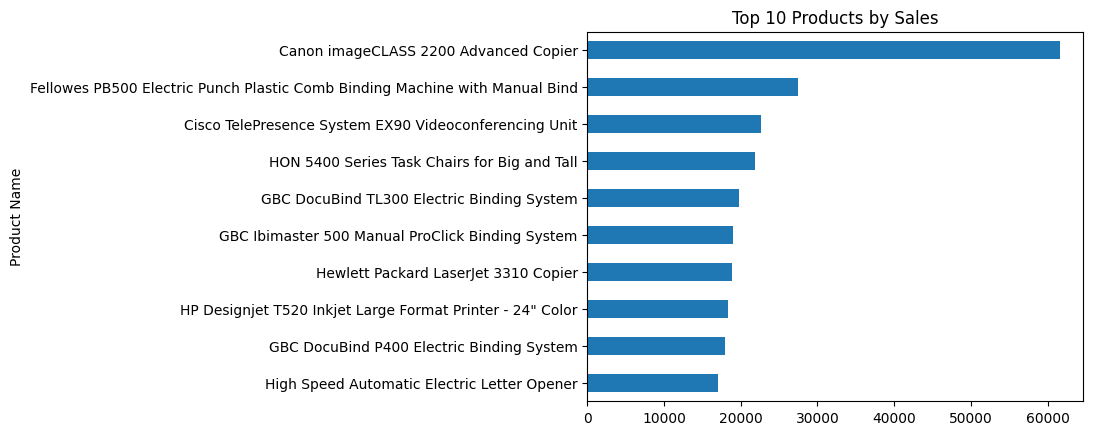

In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

top_products.sort_values(ascending = True).plot(kind = 'barh')
plt.title('Top 10 Products by Sales')
plt.show()

### 2.10 Profit by State (Geographic insight)

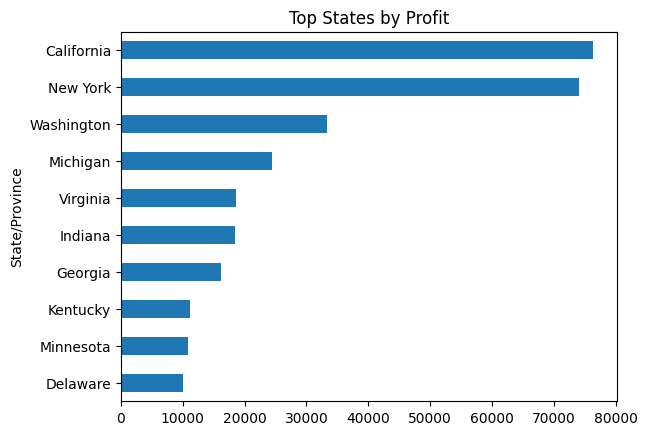

In [ ]:
state_profit = df.groupby('State/Province')['Profit'].sum()

state_profit.sort_values().tail(10).plot(kind='barh')
plt.title('Top States by Profit')
plt.show()

## Insights

High discount → negative profit

Some categories (like Furniture) often lose money

Strong seasonality in sales

Profit varies significantly by region/state

# Step 3: Dashboard (Plotly style)

In [ ]:
!pip install dash
!pip install jupyter-dash

In [ ]:
from jupyter_dash import JupyterDash
import dash
from dash import dcc, html
import plotly.express as px

In [ ]:
fig = px.bar(df, x = 'Category', y = 'Profit')
fig.show()

## Power BI Dashboard

A dashboard with:
* KPI cards (Sales, Profit, Margin)
* Filters (Region, Category)
* Time series chart
* Category comparison
* Discount vs Profit analysis

In [ ]:
# setup
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# KPI Cards
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_margin = df['Profit Margin'].mean()

print(f'Total Sales: {total_sales:,.0f}')
print(f'Total Profit: {total_profit:,.0f}')
print(f'Avg Margin: {avg_margin:.2%}')

Total Sales: 2,326,534
Total Profit: 292,297
Avg Margin: 12.22%


In [ ]:
# # KPI: Total Sales
# fig_sales = go.Figure(go.Indicator(
#     mode="number",
#     value=total_sales,
#     title={"text": "💰 Total Sales"},
#     number={'valueformat': ',.0f'}
# ))

# fig_sales.update_layout(template='plotly_white')
# fig_sales.show()


# # KPI: Total Profit
# fig_profit = go.Figure(go.Indicator(
#     mode = 'number',
#     value = total_profit,
#     title = {'text': '📈 Total Profit'},
#     number = {'valueformat': ',.0f'}
# ))

# fig_profit.update_layout(template = 'plotly_white')
# fig_profit.show()


# # KPI: Profit Margin
# fig_margin = go.Figure(go.Indicator(
#     mode = 'number',
#     value = avg_margin,
#     title = {'text': '📊 Profit Margin'},
#     number = {'valueformat': '.2%'}
# ))

# fig_margin.update_layout(template = 'plotly_white')
# fig_margin.show()

In [ ]:
# # Add consistent size + styling
# def create_kpi(title, value, format):
#     fig = go.Figure(go.Indicator(
#         mode = 'number',
#         value = value,
#         title = {'text': title},
#         number = {'valueformat': format}
#     ))

#     fig.update_layout(
#         template = 'plotly_white',
#         height = 250,
#         margin = dict(l = 20, r = 20, t = 50, b = 20)
#     )

#     return fig

# fig_sales = create_kpi('💰 Total Sales', total_sales, ',.0f')
# fig_profit = create_kpi('📈 Total Profit', total_profit, ',.0f')
# fig_margin = create_kpi('📊 Profit Margin', avg_margin, '.2%')

# fig_sales.show()
# fig_profit.show()
# fig_margin.show()

We will combine the 3 KPI cards into a single dashboard row, just like Power BI.

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [ ]:
# # prepare KPI values
# total_sales = df['Sales'].sum()
# total_profit = df['Profit'].sum()
# avg_margin = (df['Profit'] / df['Sales']).mean()


# create combined KPI dasboard
fig = make_subplots(
    rows = 1, cols = 3,
    specs = [[{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}]]
)

# Sales
fig.add_trace(go.Indicator(
    mode = 'number',
    value = total_sales,
    title = {'text': '💰 Total Sales'},
    number = {'valueformat': ',.0f'}
), row = 1, col = 1)

# Profit
fig.add_trace(go.Indicator(
    mode = 'number',
    value = total_profit,
    title = {'text': '📈 Total Profit'},
    number = {'valueformat': ',.0f'}
), row = 1, col = 2)

# Margin
fig.add_trace(go.Indicator(
    mode = 'number',
    value = avg_margin,
    title = {'text': '📊 Profit Margin'},
    number = {'valueformat': '.2%'}
), row = 1, col = 3)

fig.update_layout(
    template = 'plotly_white',
    height = 300,
    margin = dict(l = 20, r = 20, t = 50, b = 20)
)

# Add color logic
profit_color = 'green' if total_profit > 0 else 'red'

fig.data[1].number.font.color = profit_color

# Add title
fig.update_layout(
    title = 'Superstore Performance Overview',
    title_x = 0.5
)

fig.show()

Now we will turn everything into a full Power BI–style dashboard layout

We will combine:
* KPI row
* Sales trend
* Category & Region breakdown
* Discount vs Profit

All in one structured dashboard using `Plotly`

In [ ]:
# prepare data

# KPIs
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_margin = (df['Profit'] / df['Sales']).mean()

# Monthly trend
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

# Category profit
category_profit = df.groupby('Category')['Profit'].sum().reset_index()

# Region Sales
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

In [ ]:
# create dashboard layout
fig = make_subplots(
    rows = 3, cols = 3,

    specs = [
        [{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
        [{'colspan': 3, 'type': 'xy'}, None, None],
        [{'type': 'xy'}, {'type': 'xy'}, {'type': 'xy'}]
    ],

    subplot_titles = (
        'Total Sales', 'Total Profit', 'Profit Margin',
        'Monthly Sales Trend',
        'Profit by Category', 'Sales by Region', 'Discount vs Profit'
    )
)

In [ ]:
# Add KPI row
# Sales
fig.add_trace(go.Indicator(
    mode = 'number',
    value = total_sales,
    number = {'valueformat': ',.0f'}
), row = 1, col = 1)

# Profit
fig.add_trace(go.Indicator(
    mode = 'number',
    value = total_profit,
    number = {'valueformat': ',.0f'}
), row = 1, col = 2)

# Margin
fig.add_trace(go.Indicator(
    mode = 'number',
    value = avg_margin,
    number = {'valueformat': '.2%'}
), row = 1, col = 3)

# Sales Trend
fig.add_trace(go.Scatter(
    x = monthly_sales['Month'],
    y = monthly_sales['Sales'],
    mode = 'lines',
    name = 'Sales Trend'
), row = 2, col = 1)

# Category Profit
fig.add_trace(go.Bar(
    x = category_profit['Category'],
    y = category_profit['Profit'],
    name = 'Category Profit'
), row = 3, col = 1)

# Region Sales
fig.add_trace(go.Bar(
    x = region_sales['Region'],
    y = region_sales['Sales'],
    name = 'Region Sales'
), row = 3, col = 2)

# Discount vs Profit
fig.add_trace(go.Scatter(
    x = df['Discount'],
    y = df['Profit'],
    mode = 'markers',
    name = 'Discount vs Profit'
), row = 3, col = 3)


# styling
fig.update_layout(
    height = 800,
    template = 'plotly_white',
    title = 'Superstore Business Dashboard',
    title_x = 0.5,
    showlegend = False,
    margin = dict(l = 20, r = 20, t = 60, b = 20)
)

We will add interactive filters (like Power BI slicers):
* Region filter
* Category filter

All charts update dynamically

In [ ]:
# get filter values
regions = df['Region'].unique()
categories = df['Category'].unique()

Create dropdown filters

In [ ]:
# Region filter buttons
buttons = []

# "All" option
buttons.append(dict(
    label = 'All Regions',
    method = 'update',
    args = [{'visible': [True]*len(fig.data)}]
))

# Region-specific filters
for region in regions:
    visible = []

    for trace in fig.data:
        # Show all for now (we’ll refine below)
        visible.append(True)

    buttons.append(dict(
        label = region,
        method = 'update',
        args = [{'visible': visible}]
    ))

# add dropdown to dashboard
fig.update_layout(
updatemenus = [
    dict(
        buttons = buttons,
        direction = 'down',
        showactive = True,
        x = 0.1,
        y = 1.2
        )
    ]
)

But this alone does not filter data. This only toggles traces, not data, so we need a better approach.

Instead of toggling traces, we rebuild charts based on filtered data.

In [ ]:
# create filter function
def create_dashboard(filtered_df):

    monthly_sales = filtered_df.groupby('Month')['Sales'].sum().reset_index()
    category_profit = filtered_df.groupby('Category')['Profit'].sum().reset_index()
    region_sales = filtered_df.groupby('Region')['Sales'].sum().reset_index()

    fig = make_subplots(
        rows = 3, cols = 3,
        specs = [
            [{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
            [{'colspan': 3}, None, None],
            [{}, {}, {}]
        ]
    )

    # KPIs
    fig.add_trace(go.Indicator(
        mode = 'number',
        value = filtered_df['Sales'].sum(),
        title = {'text': 'Sales'}
    ), row = 1, col = 1)

    fig.add_trace(go.Indicator(
        mode = 'number',
        value = filtered_df['Profit'].sum(),
        title = {'text': 'Profit'}
    ), row = 1, col = 2)

    fig.add_trace(go.Indicator(
        mode = 'number',
        value = (filtered_df['Profit']/filtered_df['Sales']).mean(),
        title = {'text': 'Margin'}
    ), row = 1, col = 3)

    # Trend
    fig.add_trace(go.Scatter(
        x = monthly_sales['Month'],
        y = monthly_sales['Sales']
    ), row = 2, col = 1)

    # Category
    fig.add_trace(go.Bar(
        x = category_profit['Category'],
        y = category_profit['Profit']
    ), row = 3, col = 1)

    # Region
    fig.add_trace(go.Bar(
        x = region_sales['Region'],
        y = region_sales['Sales']
    ), row = 3, col = 2)

    # Scatter
    fig.add_trace(go.Scatter(
        x = filtered_df['Discount'],
        y = filtered_df['Profit'],
        mode = 'markers'
    ), row = 3, col = 3)

    fig.update_layout(height = 800, template = 'plotly_white')

    return fig

Apply filter manually

In [ ]:
# apply filter manually
filtered_df = df[df['Region'] == 'West']   # example filter
fig = create_dashboard(filtered_df)
fig.show()

# Step 4: Machine Learning Model

To predect:
* Profit
* Sales

In [ ]:
# features
features = [
    'Sales', 'Quantity', 'Discount',
    'Category', 'Region'
]

df_model = pd.get_dummies(df[features], drop_first = True)
target = df['Profit']

In [ ]:
# model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    df_model, target, test_size=0.2, random_state=42
)

model = RandomForestRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_test)

In [ ]:
# evaluate
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, preds)
print(mae)

26.676559047890645


Example insights:
* Furniture category has high sales but low profit
* High discount leads to losses
* Some states consistently underperform

## More Machine Learning

### 4.1 Random Forest Regression

In [ ]:
# feature engineering
df_ml = df.copy()

# Time features
df_ml['Year'] = df_ml['Order Date'].dt.year
df_ml['Month'] = df_ml['Order Date'].dt.month

# Business features
df_ml['Profit Margin'] = df_ml['Profit'] / df_ml['Sales']
df_ml['Sales per Quantity'] = df_ml['Sales'] / df_ml['Quantity']

# drop useless text columns
drop_cols = [
    'Row ID',
    'Order ID',
    'Customer Name',
    'Product Name',
    'Order Date',
    'Ship Date'
]

df_ml = df_ml.drop(columns=drop_cols, errors='ignore')

In [ ]:
df_ml

,Ship Mode,Customer ID,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,Profit Margin,Sales per Quantity
0,Standard Class,DP-13000,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,16.448,2,0.2,5.5512,2023,1,0.3375,8.224
1,Standard Class,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,3.540,2,0.8,-5.4870,2023,1,-1.5500,1.770
2,Standard Class,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,11.784,3,0.2,4.2717,2023,1,0.3625,3.928
3,Standard Class,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,272.736,3,0.2,-64.7748,2023,1,-0.2375,90.912
4,Standard Class,MB-18085,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,19.536,3,0.2,4.8840,2023,1,0.2500,6.512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,52.776,3,0.2,19.7910,2026,12,0.3750,17.592
10190,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,20.720,2,0.2,6.4750,2026,12,0.3125,10.360
10191,Standard Class,JM-15580,Consumer,United States,Loveland,Colorado,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,3.024,3,0.2,-0.6048,2026,12,-0.2000,1.008
10192,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,90.930,7,0.0,2.7279,2026,12,0.0300,12.990


In [ ]:
# Encode categories
df_ml = pd.get_dummies(df_ml, drop_first=True)

In [ ]:
df_ml

,Sales,Quantity,Discount,Profit,Year,Month,Profit Margin,Sales per Quantity,Ship Mode_Same Day,Ship Mode_Second Class,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,16.448,2,0.2,5.5512,2023,1,0.3375,8.224,False,False,...,False,False,False,False,False,True,False,False,False,False
1,3.540,2,0.8,-5.4870,2023,1,-1.5500,1.770,False,False,...,False,False,False,False,False,False,False,False,False,False
2,11.784,3,0.2,4.2717,2023,1,0.3625,3.928,False,False,...,False,False,False,True,False,False,False,False,False,False
3,272.736,3,0.2,-64.7748,2023,1,-0.2375,90.912,False,False,...,False,False,False,False,False,False,False,True,False,False
4,19.536,3,0.2,4.8840,2023,1,0.2500,6.512,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,52.776,3,0.2,19.7910,2026,12,0.3750,17.592,False,False,...,False,False,False,False,False,False,False,False,False,False
10190,20.720,2,0.2,6.4750,2026,12,0.3125,10.360,False,False,...,False,False,False,False,False,False,False,False,False,False
10191,3.024,3,0.2,-0.6048,2026,12,-0.2000,1.008,False,False,...,False,True,False,False,False,False,False,False,False,False
10192,90.930,7,0.0,2.7279,2026,12,0.0300,12.990,False,False,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Columns: 3951 entries, Sales to Sub-Category_Tables
dtypes: bool(3943), float64(5), int32(2), int64(1)
memory usage: 38.9 MB


In [ ]:
# define model
from sklearn.model_selection import train_test_split

X = df_ml.drop(columns = ['Profit'])
y = df_ml['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# train the model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
# evaluate
from sklearn.metrics import mean_absolute_error, r2_score

preds_rf = model.predict(X_test)

print('MAE_rf:', mean_absolute_error(y_test, preds_rf))
print('R2_rf:', r2_score(y_test, preds_rf))

# feature importance
importance_rf = pd.Series(model.feature_importances_, index = X.columns)
importance_rf.sort_values(ascending = False).head(10)

MAE_rf: 7.898083667369043
R2_rf: 0.9008577984982722


,0
Sales,0.458045
Profit Margin,0.262917
Product ID_TEC-CO-10004722,0.065059
Product ID_TEC-MA-10000418,0.058161
Sales per Quantity,0.036542
Discount,0.020459
Product ID_OFF-BI-10001120,0.010565
Product ID_TEC-MA-10004125,0.006823
Customer ID_CS-12505,0.006375
Month,0.005797


Actual vs Prediction

In [ ]:
results_rf = pd.DataFrame({
    'Actual': y_test,
    'Predicted': preds_rf
})

fig_rf = px.scatter(
    results_rf, x = 'Actual', y = 'Predicted', title = 'Random Forest Actual vs Predicted'
)

# prediction line
fig_rf.add_shape(
    type = 'line',
    x0 = results_rf['Actual'].min(),
    y0 = results_rf['Actual'].min(),
    x1 = results_rf['Actual'].max(),
    y1 = results_rf['Actual'].max(),
    line = dict(dash = 'dash')
)

fig_rf.show()

Error Analysis

In [ ]:
results_rf['Error'] = results_rf['Actual'] - results_rf['Predicted']

fig_rf2 = px.scatter(
    results_rf, x = 'Predicted', y = 'Error', title = 'Random Forest Error Plot'
)

fig_rf2.add_hline(y = 0, line_dash = 'dash')

fig_rf2.show()

Error Distribution

In [ ]:
fig_rf3 = px.histogram(
    results_rf, x = 'Error', nbins = 50, title = 'Random Forest Error Distribution'
)

fig_rf3.show()

### 4.2 Grid Search

Hyperparameter tuning using Grid Search

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestRegressor

# param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [10, 20, None],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2]
# }

# rf = RandomForestRegressor(random_state = 42)

# grid = GridSearchCV(
#     rf, param_grid, cv = 3, scoring = 'neg_mean_absolute_error', n_jobs = -1
# )

# grid.fit(X_train, y_train)

# best_model = grid.best_estimator_

### 4.3 Random Search

Grid Search took too long to process (40 min and still not done yet). Therefore, we will use Random Search instead.

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV

# random = RandomizedSearchCV(
#     model,
#     param_distributions=param_grid,
#     n_iter=20,
#     cv=3,
#     random_state=42
# )

# random.fit(X_train, y_train)

# best_model = random.best_estimator_

Still took long time

### 4.4 Bayesian Optimization

We will use Optuna to tune XGBoost

In [ ]:
pip install optuna xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.5 MB/s eta 0:00:00


In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

Define objective function

In [ ]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5)
    }

    xgboost = XGBRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    xgboost.fit(X_train, y_train)

    preds = xgboost.predict(X_test)

    return mean_absolute_error(y_test, preds)

Run optimization

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

[I 2026-04-02 14:12:14,383] A new study created in memory with name: no-name-8d01c3a5-0be1-4e3e-a7b8-aae2c3fa5262
[I 2026-04-02 14:12:44,549] Trial 0 finished with value: 11.121340627958592 and parameters: {'n_estimators': 498, 'max_depth': 3, 'learning_rate': 0.27868442425606815, 'subsample': 0.908311209228226, 'colsample_bytree': 0.807142760219258, 'gamma': 1.625509627353234}. Best is trial 0 with value: 11.121340627958592.
[I 2026-04-02 14:13:40,698] Trial 1 finished with value: 9.575897189224813 and parameters: {'n_estimators': 495, 'max_depth': 11, 'learning_rate': 0.02221542232930571, 'subsample': 0.9254802181740716, 'colsample_bytree': 0.6092573926962221, 'gamma': 4.784105805593212}. Best is trial 1 with value: 9.575897189224813.
[I 2026-04-02 14:14:09,432] Trial 2 finished with value: 13.86408220244227 and parameters: {'n_estimators': 433, 'max_depth': 3, 'learning_rate': 0.2809529200993135, 'subsample': 0.7500306939971133, 'colsample_bytree': 0.8393910488294625, 'gamma': 0.644

Get the best model

In [ ]:
best_params = study.best_params

best_xgb = XGBRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9740381057351554, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=2.6161947837613204, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.043256235562670955,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=12, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=176, n_jobs=-1,
             num_parallel_tree=None, ...)

In [ ]:
best_params

{'n_estimators': 176,
 'max_depth': 12,
 'learning_rate': 0.043256235562670955,
 'subsample': 0.8896673655629712,
 'colsample_bytree': 0.9740381057351554,
 'gamma': 2.6161947837613204}

Evaluate

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

preds_xgb = best_xgb.predict(X_test)

print("MAE_xgb:", mean_absolute_error(y_test, preds_xgb))
print("R2_xgb:", r2_score(y_test, preds_xgb))

MAE_xgb: 7.127788827695669
R2_xgb: 0.8574201670744515


Visualize the optimization

In [ ]:
import optuna.visualization as vis

vis.plot_optimization_history(study)
vis.plot_param_importances(study)

Actual vs Prediction

In [ ]:
results_xgb = pd.DataFrame({
    'Actual': y_test,
    'Predicted': preds_xgb
})

fig_xgb = px.scatter(
    results_xgb, x = 'Actual', y = 'Predicted', title = 'XGBoost Actual vs Predicted'
)

# prediction line
fig_xgb.add_shape(
    type = 'line',
    x0 = results_xgb['Actual'].min(),
    y0 = results_xgb['Actual'].min(),
    x1 = results_xgb['Actual'].max(),
    y1 = results_xgb['Actual'].max(),
    line = dict(dash = 'dash')
)

fig_xgb.show()

Error Analysis

In [ ]:
results_xgb['Error'] = results_xgb['Actual'] - results_xgb['Predicted']

fig_xgb2 = px.scatter(
    results_xgb, x = 'Predicted', y = 'Error', title = 'XGBoost Error Plot'
)

fig_xgb2.add_hline(y = 0, line_dash = 'dash')

fig_xgb2.show()

Error Distribution

In [ ]:
fig_xgb3 = px.histogram(
    results_xgb, x = 'Error', nbins = 50, title = 'XGBoost Error Distribution'
)

fig_xgb3.show()

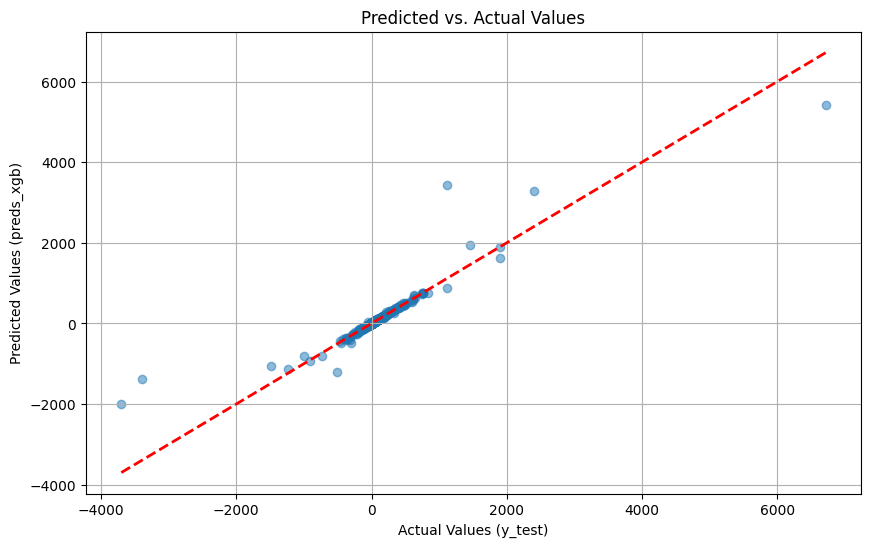

In [170]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data - Replace with your actual y_test and y_pred
# y_test = [...]
# y_pred = [...]

plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds_xgb, alpha=0.5)

# Plot the 45-degree line (perfect prediction line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', lw=2)

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (preds_xgb)')
plt.title('Predicted vs. Actual Values')
plt.grid(True)
plt.show()

Why XGBoost + Optuna is powerful?

XGBoost → strong predictive model

Optuna → finds best parameters efficiently

👉 Together = state-of-the-art tabular ML

Optuna is used for Bayesian Optimization to efficiently tune an XGBoost model, improving performance by exploring the hyperparameter space intelligently.

# Key Findings

**1. Discount vs Profit**

Higher discounts are associated with lower profit.

Strong negative correlation.

Insight:

Excessive discounting reduces profitability.

**2. Sales ≠ Profit**

High sales do not always lead to high profit.

Some high-revenue categories have low margins.

Insight:

Revenue-focused strategies can hide losses.

**3. Regional Differences**

Some regions outperform others in profit.

Sales distribution is uneven.

nsight:

Opportunity for regional optimization.

**4. Product Category Impact**

Certain categories drive most profit.

Others contribute low or negative profit.

Insight:

Focus on high-margin categories.

## Machine Learning Insights

* Built a predictive model using XGBoost
* Tuned using Bayesian Optimization

Identified key drivers:
* Discount
* Quantity
* Category

Insight:

Profit is highly sensitive to discount strategy

## Discussion

* Business decisions should balance sales growth vs profitability
* Discounts should be strategically controlled

Predictive models can support:
* Pricing decisions
* Promotion planning

## Future Improvements

* Deploy model as web app
* Add real-time prediction
* Improve feature engineering
* Use advanced models (e.g., LightGBM)